In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/fashion_trends_cleaned.csv")

df.head()

,trend_name,macrotrend,microtrend_level,source_platform,brand_source,region,year,season,color_primary,color_secondary,...,maximalism_level,commercial_adoption,search_interest,growth_percent,tiktok_presence,pinterest_presence,runway_presence,fast_fashion_presence,description,trend_score
0,balloon silhouette,organic realism,3,Vogue,Jacquemus,Global,2026,Spring-Summer,soft pink,black,...,4,2,0,0,2,3,3,2,"""Rounded oversized silhouettes inspired by flu...",1.9
1,draped elegance,quiet luxury,2,Vogue,Christian Dior,Global,2026,Spring-Summer,ivory,gray,...,2,3,0,0,1,2,3,3,"""Soft draping and wrapped constructions emphas...",1.5
2,fringe motion,artisanal sophistication,3,Vogue,Bottega Veneta,Global,2026,Spring-Summer,white,red,...,7,2,0,0,2,2,3,2,"""Fringes used to create movement and tactile v...",1.7
3,3d floral embroidery,organic realism,3,Vogue,Balenciaga,Global,2026,Spring-Summer,cream,red,...,8,2,0,0,3,3,3,2,"""Three-dimensional floral textures inspired by...",2.1
4,feather drama,maximalist fantasy,2,Vogue,Chanel,Global,2026,Spring-Summer,black,red,...,10,2,0,0,2,3,3,3,"""Feather-inspired garments emphasizing dramati...",1.9


In [5]:
df["survival_score"] = (
    df["utility_level"] * 0.25 +
    df["commercial_adoption"] * 0.25 +
    df["minimalism_level"] * 0.15 +
    df["runway_presence"] * 0.10 +
    df["pinterest_presence"] * 0.10 +
    df["movement_level"] * 0.05 +
    df["volume_level"] * -0.05 +
    df["maximalism_level"] * -0.15 +
    df["tiktok_presence"] * -0.10
)

df[["trend_name", "survival_score"]].head(10)

,trend_name,survival_score
0,balloon silhouette,1.550000e+00
1,draped elegance,2.400000e+00
2,fringe motion,1.100000e+00
3,3d floral embroidery,2.000000e-01
4,feather drama,1.665335e-16
5,visible midriff,2.250000e+00
6,layered volume,-5.000000e-02
7,quiet luxury,3.050000e+00
8,gorpcore,3.500000e+00
9,coquette aesthetic,1.300000e+00


In [6]:
def classify_survival(score):

    if score >= 2:
        return "long_lasting"

    elif score >= 1:
        return "evolving"

    else:
        return "microtrend"

df["trend_survival_type"] = df["survival_score"].apply(classify_survival)

df[["trend_name", "survival_score", "trend_survival_type"]]

,trend_name,survival_score,trend_survival_type
0,balloon silhouette,1.550000e+00,evolving
1,draped elegance,2.400000e+00,long_lasting
2,fringe motion,1.100000e+00,evolving
3,3d floral embroidery,2.000000e-01,microtrend
4,feather drama,1.665335e-16,microtrend
5,visible midriff,2.250000e+00,long_lasting
6,layered volume,-5.000000e-02,microtrend
7,quiet luxury,3.050000e+00,long_lasting
8,gorpcore,3.500000e+00,long_lasting
9,coquette aesthetic,1.300000e+00,evolving


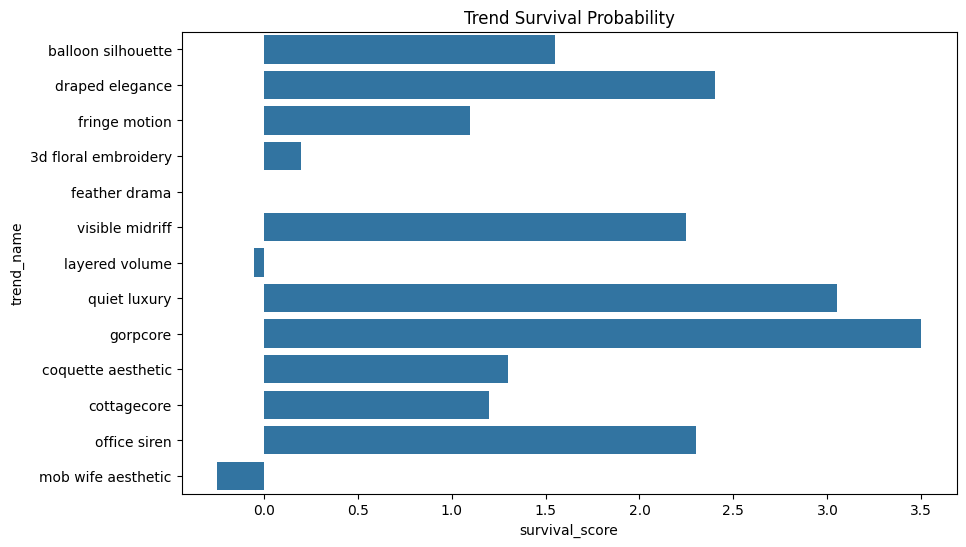

In [7]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="survival_score",
    y="trend_name"
)

plt.title("Trend Survival Probability")
plt.show()

In [8]:
surviving_trends = df[
    df["trend_survival_type"] != "microtrend"
]

surviving_trends[[
    "trend_name",
    "macrotrend",
    "color_primary",
    "silhouette_main",
    "mood_aesthetic"
]]

,trend_name,macrotrend,color_primary,silhouette_main,mood_aesthetic
0,balloon silhouette,organic realism,soft pink,balloon,editorial elegance
1,draped elegance,quiet luxury,ivory,draped,sophisticated calm
2,fringe motion,artisanal sophistication,white,oversized,dynamic movement
5,visible midriff,sensual minimalism,beige,straight,confident sensuality
7,quiet luxury,minimalism,earth tones,relaxed,sophisticated calm
8,gorpcore,utility wear,olive,oversized,functional streetwear
9,coquette aesthetic,romantic revival,pink,fitted,hyper femininity
10,cottagecore,nature escapism,cream,flowy,rural romanticism
11,office siren,corporate sensuality,black,fitted,power sensuality


In [9]:
import random

trend_1 = surviving_trends.sample(1).iloc[0]
trend_2 = surviving_trends.sample(1).iloc[0]

new_trend = {
    "new_trend_name":
        trend_1["mood_aesthetic"] +
        " " +
        trend_2["silhouette_main"],

    "primary_color":
        trend_1["color_primary"],

    "secondary_color":
        trend_2["color_primary"],

    "inspired_by":
        trend_1["trend_name"] +
        " + " +
        trend_2["trend_name"]
}

print(new_trend)

{'new_trend_name': 'sophisticated calm balloon', 'primary_color': 'earth tones', 'secondary_color': 'soft pink', 'inspired_by': 'quiet luxury + balloon silhouette'}


In [10]:
for i in range(10):

    trend_1 = surviving_trends.sample(1).iloc[0]
    trend_2 = surviving_trends.sample(1).iloc[0]

    print(
        trend_1["mood_aesthetic"],
        trend_2["silhouette_main"]
    )

hyper femininity oversized
confident sensuality relaxed
hyper femininity fitted
confident sensuality fitted
hyper femininity flowy
hyper femininity fitted
sophisticated calm draped
rural romanticism straight
dynamic movement relaxed
hyper femininity fitted
